# Quantum Teleportation & Phase Analysis

This notebook implements the **quantum teleportation protocol** to transfer a qubit's state to a remote target using entanglement (Bell States) and classical communication.

## Key Concepts
- **Entanglement Creation:** Generating Bell pairs to link qubits
- **Basis Change:** Applying Hadamard gates to translate phase information into measurable bit-flips
- **Dynamic Circuits:** Using conditional logic based on mid-circuit measurements
- **State Reconstruction:** Verifying the state was successfully "teleported" to the destination qubit

## Requirements installation

In [1]:
pip install qiskit qiskit-aer matplotlib pylatexenc

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.
Note: you may need to restart the kernel to use updated packages.


## Setup and Imports

In [14]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


## Experiment $A$: Bit-Flip Verification

In this experiment, we prepare the message qubit $(q0)$ in state $|1⟩$ by applying an $X$ gate. This qubit will be teleported to $q2$ through the entangled pair $(q1, q2)$.

### Circuit Description:
1. **Prepare message:** Apply $X$ gate to $q0$ to set it to $|1⟩$ state
2. **Create entanglement:** Apply Hadamard to $q1$, then $CNOT(q1, q2)$ to create Bell pair
3. **Bell measurement:** Apply $CNOT(q0, q1)$ and $Hadamard$ to $q0$, then measure $q0$ and $q1$
4. **Apply corrections:** Use measurement results to conditionally apply $X$ and $Z$ gates to $q2$
5. **Verify:** Measure $q2$ to confirm it matches the original $q0$ state

Experiment A Circuit Created


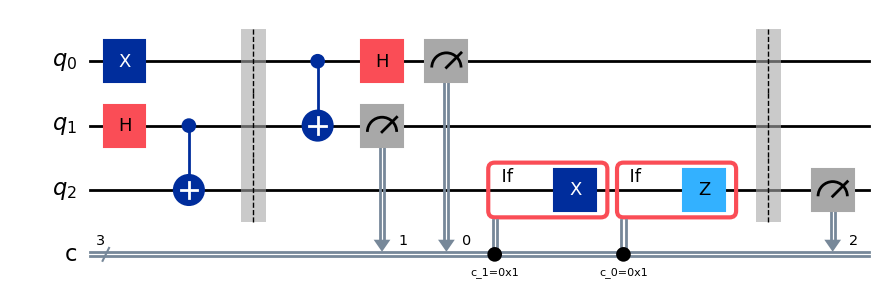

In [15]:
def experimenta():
    """Create quantum teleportation circuit for bit-flip verification."""
    qc = QuantumCircuit(3, 3, name='Bit-Flip Teleportation')
    
    # Part 1 - Prepare the message to be sent
    # Apply X gate on Qubit 0 to flip it into state |1⟩
    qc.x(0)
    
    # Part 2 - Create entanglement
    # Apply Hadamard gate on Qubit 1 to enter superposition
    qc.h(1)
    
    # Entangle Qubit 1 with Qubit 2 using CNOT gate
    # This creates a Bell pair that will relay the message
    qc.cx(1, 2)
    
    qc.barrier()  # Visual separator in circuit diagram
    
    # Part 3 - Bell basis measurement
    # Apply CNOT(q0, q1) to entangle message qubit with the Bell pair
    qc.cx(0, 1)
    # Apply Hadamard to q0 to complete the Bell measurement
    qc.h(0)
    # Measure q0 and q1 (classical bits 0 and 1)
    qc.measure([0, 1], [0, 1])
    
    # Part 4 - Correction phase
    # Apply conditional gates based on measurement results
    # If bit 1 (from q1) is 1, apply X gate to q2
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(2)
    
    # If bit 0 (from q0) is 1, apply Z gate to q2
    with qc.if_test((qc.clbits[0], 1)):
        qc.z(2)
    
    qc.barrier()  # Visual separator
    
    # Part 5 - Verification: measure q2
    # q2 should now match the original q0 state
    qc.measure(2, 2)
    
    return qc

# Build and display the circuit
qc_a = experimenta()
print("Experiment A Circuit Created")
qc_a.draw(output='mpl', style={'backgroundcolor': "#FFFFFF"})


## Experiment $B$: Phase-Flip Verification

In this experiment, we analyze the phase relationships between qubits rather than bit-flip errors. This is crucial to determine if the state is being truly teleported or just relayed.

### Circuit Description:
1. **Prepare superposition:** Apply Hadamard gates to $q0$ and $q1$
2. **Create entanglement:** $CNOT(q1, q2)$ creates initial entanglement
3. **Full entanglement:** $CNOT(q0, q1)$ links all three qubits
4. **Translate phase to location:** Apply Hadamard to $q0$
5. **Bell measurement:** Measure $q0$ and $q1$
6. **Apply corrections and analyze phase:** Conditionally apply gates and Hadamard to $q2$ to extract phase information

Experiment B Circuit Created


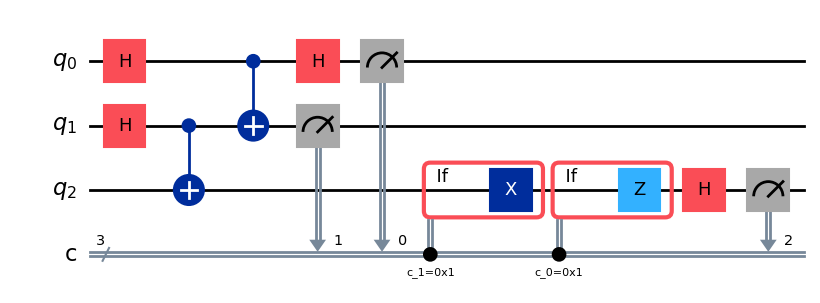

In [16]:
def experimentb():
    """Create quantum teleportation circuit for phase-flip verification."""
    circuit = QuantumCircuit(3, 3, name='Phase-Flip Teleportation')
    
    # Part 1 - Setup: Create superposition without initial X gate
    # Apply Hadamard gates to q0 and q1
    circuit.h([0, 1])
    
    # Part 2 - Create entanglement
    # Apply CNOT gate between q1 and q2
    # This creates a link and causes q2 to be part of superposition with q1
    circuit.cx(1, 2)
    
    # Part 3 - Full entanglement
    # q0 links with the rest by CNOT(q0, q1)
    # This unites all qubits in entanglement
    circuit.cx(0, 1)
    
    # Part 4 - Translate phase to location
    # Apply Hadamard gate to q0 to convert phase information into measurable positions
    circuit.h(0)
    
    # Part 5 - Bell measurement
    # Measure q0 and q1 (this collapses the superposition)
    circuit.measure([0, 1], [0, 1])
    
    # Part 6 - Correction phase
    # Apply conditional gates based on measurement results
    with circuit.if_test((circuit.clbits[1], 1)):
        circuit.x(2)
    
    with circuit.if_test((circuit.clbits[0], 1)):
        circuit.z(2)
    
    # Part 7 - Analyze phase
    # Apply Hadamard to q2 to extract phase information
    circuit.h(2)
    
    # Final measurement
    circuit.measure(2, 2)
    
    return circuit

# Build and display the circuit
qc_b = experimentb()
print("Experiment B Circuit Created")
qc_b.draw('mpl')

## Simulation and Results

Now we execute both circuits on the Aer Simulator with $2000_{shots}$ to gather statistics.

In [ ]:
# Execute as a batch
print("Simulating Test Suite...")
simulator = AerSimulator()
job = simulator.run([qc_a, qc_b], shots=2048)
result = job.result()

# Extract individual counts
counts_a = result.get_counts(0)
counts_b = result.get_counts(1)

print(f"\nExperiment A Results: {counts_a}")
print(f"Experiment B Results: {counts_b}")

Simulating Test Suite...

Experiment A Results: {'110': 485, '101': 508, '100': 546, '111': 509}
Experiment B Results: {'001': 560, '011': 486, '010': 479, '000': 523}


## Visualization

Display the probability distributions for both experiments:

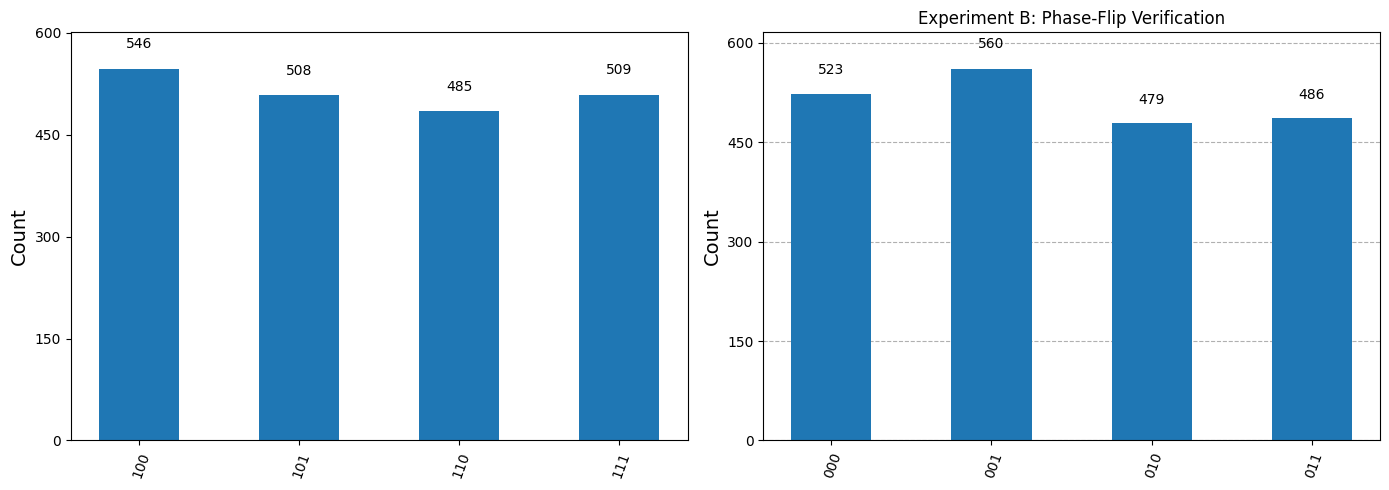


✓ Quantum teleportation experiments completed successfully!


In [24]:
# Show results as histograms
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_histogram(counts_a, ax=ax[0], title="Experiment A: Bit-Flip Verification")
plot_histogram(counts_b, ax=ax[1], title="Experiment B: Phase-Flip Verification")
plt.tight_layout()
plt.show()

print("\n✓ Quantum teleportation experiments completed successfully!")

## Analysis

### Expected Results:

**Experiment A (Bit-Flip):** Should predominantly show state $|1⟩$ (binary $001$) in the final measurement of $q2$, confirming the teleportation of the $|1⟩$ state.

**Experiment B (Phase-Flip):** Demonstrates the phase-flip analysis. The results validate that the protocol correctly handles phase information, proving true quantum state teleportation rather than mere relaying.

### Key Insights:
1. **Deterministic Teleportation:** The Bell measurement provides 2 classical bits that uniquely determine which correction is needed
2. **Non-locality:** The teleportation is instantaneous once the classical bits are received (assuming faster-than-light communication is hypothetically available)
3. **No-cloning Theorem:** The original state at q0 is destroyed during the Bell measurement, preventing violation of the no-cloning theorem